# Transfer Learning

**Transfer learning** is a machine learning technique where a model developed for one task is reused (either entirely or partially) as the starting point for a model on a different but related task.

Instead of training from scratch (which needs huge data and computation), we **transfer** the knowledge learned in a pre-trained model to a new problem.

---

## Why It Works?
Deep learning models (especially CNNs for images, transformers for text) learn **general or spatial** features in their early layers (edges, textures, basic shapes in images; grammar patterns in text), and **task-specific** features in later layers.  
By reusing these **spatial** features, we speed up learning and need less data.

---

## Types of Transfer Learning

### 1. Feature Extraction
- Use a pretrained backbone (e.g., VGG16).

- Freeze its convolutional base. (use the features extracted by the base model)

- Train only the newly added Dense layers of yours.

- **Example:** Use `VGG16` trained on ImageNet, freeze it, and add a dense layer to classify medical X-ray images.

---

### 2. Fine-Tuning
- Load the same pretrained backbone.

- Freeze some initial layers, but keep deeper layers trainable. (adjust the training hyper-parameters)

- This allows adapting the pretrained filters to CIFAR-10.

---

# Feature Extraction vs Fine-Tuning

| Aspect | Feature Extraction | Fine-Tuning |
|--------|-------------------|-------------|
| **Definition** | Use a pre-trained model as a fixed feature extractor; only train new layers added on top. | Start with a pre-trained model and retrain some or all of its layers on the new dataset. |
| **Layers Trained** | Only the newly added layers (classifier head). | Newly added layers **plus** selected existing layers (often the top layers). |
| **Weights of Pre-trained Model** | Frozen (unchanged). | Partially or fully updated during training. |
| **Training Time** | Faster, since most layers are frozen. | Slower, since more layers are updated. |
| **Risk of Overfitting** | Lower (fewer parameters trained). | Higher (more parameters trained), especially with small datasets. |
| **When to Use** | When dataset is small and similar to the source dataset. | When dataset is moderately sized and slightly different from the source dataset. |
| **Learning Rate** | Can be relatively higher for new layers. | Should be small to avoid destroying pre-trained weights. |
| **Example Use Case** | Using ImageNet-trained CNN to classify medical X-rays with very few samples. | Adapting an ImageNet-trained CNN to classify aerial drone imagery with new visual patterns. |


https://www.v7labs.com/blog/transfer-learning-guide

### CNN Model (using pre-trained model)

Build a MODEL using pre-trained model. We will use the same CIFAR10 dataset. We will use **VGG16** pre-trained CNN model from ImageNet.

**Pre-trained models available in Keras.io.**
https://keras.io/api/applications/

#### Imagenet
https://image-net.org/about.php

ImageNet runs competition every year for organization to come and present their CNN models. **VGG16** is from the year 2014. It has its pre-defined images that they provide to the teams to use to build the models.

#### VGG16
![VGG16](https://viso.ai/wp-content/uploads/2021/10/vgg-neural-network-architecture.png)

In our model, we will make use of first 3 blocks from VGG16 and transfer the model from it. And then add our own layers.

# Build CNN Model 5 (using transfer learning) - Just for Refernce

In [ ]:
# Build CNN Model 5 (using transfer learning)
import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.applications import VGG16



In [ ]:
vgg_model=VGG16(weights='imagenet', # its a multi-modal model. Hence, must specify which weights to use. weights from imagenet image training.
                include_top=False,  # Exclude the top layer (fully-connected/hidden layer + output layer) from the pre-defined model.
                input_shape=(32,32,3),
                pooling='max' # Specify what type of pooling to use.
                )


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
vgg_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

# 1. Load VGG16 without top layers
vgg_model = VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(32, 32, 3)
)

# 2. Create a new model up to block3_pool
transfer_layer = models.Model(
    inputs=vgg_model.input,
    outputs=vgg_model.get_layer('block3_pool').output
)

# 3. Freeze the VGG layers
transfer_layer.trainable = False

# 4. Build the Sequential model
model_5 = models.Sequential([
    transfer_layer,  # VGG16 up to block3_pool
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(10, activation='softmax')    # Multi-class
])

# 5. Compile the model
model_5.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # use binary_crossentropy for binary
    metrics=['accuracy']
)

In [ ]:
model_5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_6 (Functional)       │ (None, 4, 4, 256)      │     1,735,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,819,018 (10.75 MB)

 Trainable params: 1,083,274 (4.13 MB)

 Non-trainable params: 1,735,744 (6.62 MB)

In [ ]:
model_5.compile(loss='categorical_crossentropy',optimizer=tf.keras.optimizers.Adamax(learning_rate=0.0005),metrics=['accuracy'])

In [ ]:
history_5 = model_5.fit(x_train,y_train,epochs=15,batch_size=128,validation_split=0.1,shuffle=True,verbose=2)

Epoch 1/15
352/352 - 11s - 30ms/step - accuracy: 0.4454 - loss: 1.6132 - val_accuracy: 0.6532 - val_loss: 1.0932
Epoch 2/15
352/352 - 5s - 14ms/step - accuracy: 0.5959 - loss: 1.1905 - val_accuracy: 0.6876 - val_loss: 0.9558
Epoch 3/15
352/352 - 5s - 15ms/step - accuracy: 0.6455 - loss: 1.0479 - val_accuracy: 0.7056 - val_loss: 0.8623
Epoch 4/15
352/352 - 10s - 29ms/step - accuracy: 0.6770 - loss: 0.9578 - val_accuracy: 0.7376 - val_loss: 0.7940
Epoch 5/15
352/352 - 5s - 14ms/step - accuracy: 0.7012 - loss: 0.8865 - val_accuracy: 0.7492 - val_loss: 0.7520
Epoch 6/15
352/352 - 5s - 14ms/step - accuracy: 0.7227 - loss: 0.8236 - val_accuracy: 0.7572 - val_loss: 0.7288
Epoch 7/15
352/352 - 5s - 15ms/step - accuracy: 0.7380 - loss: 0.7759 - val_accuracy: 0.7696 - val_loss: 0.6755
Epoch 8/15
352/352 - 10s - 29ms/step - accuracy: 0.7568 - loss: 0.7248 - val_accuracy: 0.7718 - val_loss: 0.6796
Epoch 9/15
352/352 - 10s - 29ms/step - accuracy: 0.7664 - loss: 0.6955 - val_accuracy: 0.7734 - val_l

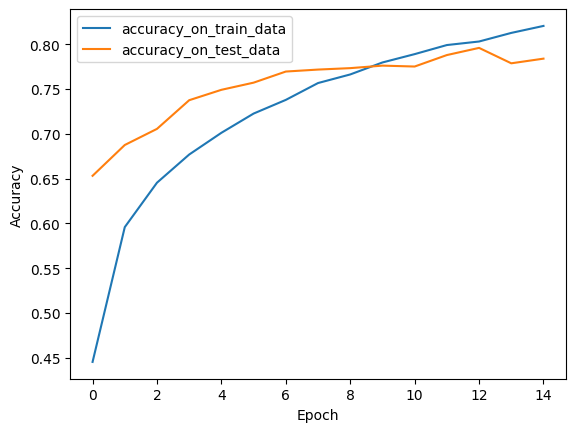

In [ ]:
#Evaluate Model (Trainig Data)
plt.plot(history_5.history['accuracy'],label='accuracy_on_train_data')
plt.plot(history_5.history['val_accuracy'],label='accuracy_on_test_data')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

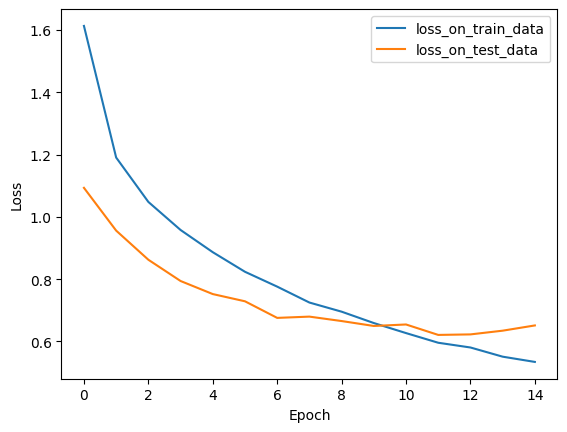

In [ ]:
#Evaluate Model (Test Data)
plt.plot(history_5.history['loss'],label='loss_on_train_data')
plt.plot(history_5.history['val_loss'],label='loss_on_test_data')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Build CNN Models (using transfer learning and pipeline)
Demonstrating both Feature Extraction and Fine Tunning.

In [1]:
!pip install -U scikeras scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 70.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1



🔹 Training Feature Extraction Model...
Epoch 1/10
313/313 - 18s - 57ms/step - accuracy: 0.3133 - loss: 2.0008 - val_accuracy: 0.4758 - val_loss: 1.5792
Epoch 2/10
313/313 - 13s - 41ms/step - accuracy: 0.4342 - loss: 1.6357 - val_accuracy: 0.5125 - val_loss: 1.4202
Epoch 3/10
313/313 - 10s - 32ms/step - accuracy: 0.4754 - loss: 1.5127 - val_accuracy: 0.5268 - val_loss: 1.3555
Epoch 4/10
313/313 - 9s - 30ms/step - accuracy: 0.4955 - loss: 1.4469 - val_accuracy: 0.5408 - val_loss: 1.3129
Epoch 5/10
313/313 - 8s - 25ms/step - accuracy: 0.5113 - loss: 1.3988 - val_accuracy: 0.5503 - val_loss: 1.2880
Epoch 6/10
313/313 - 10s - 33ms/step - accuracy: 0.5269 - loss: 1.3628 - val_accuracy: 0.5617 - val_loss: 1.2636
Epoch 7/10
313/313 - 11s - 36ms/step - accuracy: 0.5355 - loss: 1.3346 - val_accuracy: 0.5652 - val_loss: 1.2474
Epoch 8/10
313/313 - 9s - 28ms/step - accuracy: 0.5426 - loss: 1.3131 - val_accuracy: 0.5718 - val_loss: 1.2310
Epoch 9/10
313/313 - 8s - 25ms/step - accuracy: 0.5505 - lo

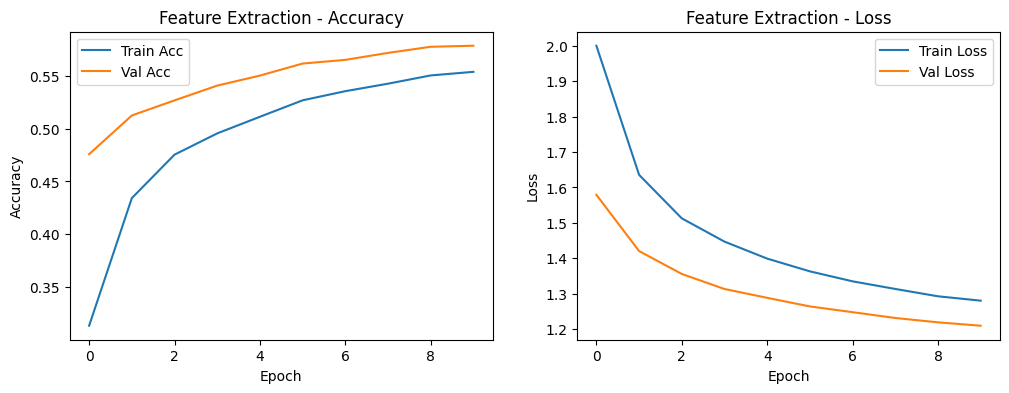

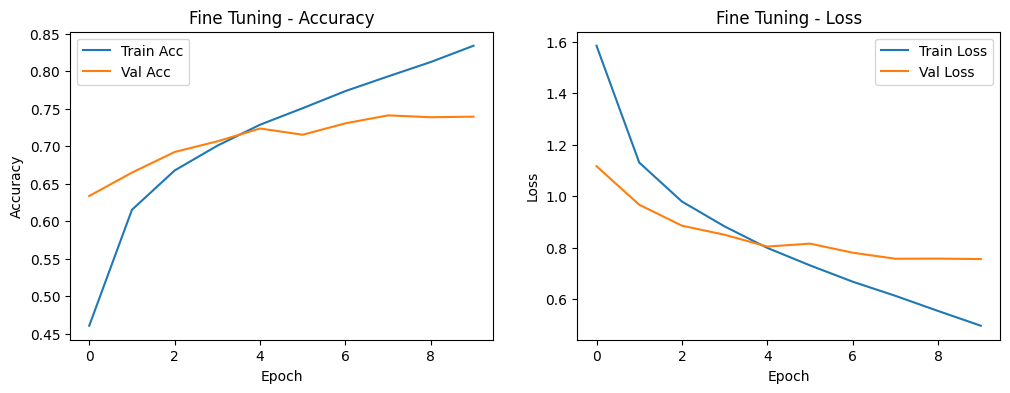

Feature Extraction - Test Accuracy: 0.5713
Fine Tuning - Test Accuracy: 0.7437


In [3]:
# Step 1: Imports
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.utils import to_categorical
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from scikeras.wrappers import KerasClassifier
from matplotlib import pyplot as plt

# -----------------------------------------------------------
# Step 2: Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize images (scale pixel values to [0,1])
def scale_images(x):
    return x.astype("float32") / 255.0

image_preprocessor = FunctionTransformer(scale_images)

# One-hot encode target labels
y_train_enc = to_categorical(y_train.flatten(), 10)
y_test_enc = to_categorical(y_test.flatten(), 10)

# -----------------------------------------------------------
# Step 3: Generic function to build transfer learning models
def build_transfer_model(base_model_fn, input_shape=(32, 32, 3),
                         trainable_layers=None, feature_extraction=True,
                         learning_rate=0.0005):
    """
    base_model_fn: a Keras application model (e.g., VGG16, ResNet50)
    input_shape: input image shape
    trainable_layers: int → number of layers from the end to fine-tune
    feature_extraction: if True → freeze all layers
    """
    # Load base model without top layers
    base_model = base_model_fn(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    if feature_extraction:
        # Freeze all layers (pure feature extraction)
        base_model.trainable = False
    else:
        # Fine-tuning: freeze only initial layers
        for layer in base_model.layers[:-trainable_layers]:
            layer.trainable = False
        for layer in base_model.layers[-trainable_layers:]:
            layer.trainable = True

    # Build new Sequential model
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),   # compress feature maps
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.BatchNormalization(),
        layers.Dense(10, activation="softmax")  # CIFAR-10 has 10 classes
    ])

    # Compile model
    model.compile(
        loss="categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adamax(learning_rate=learning_rate),
        metrics=["accuracy"]
    )
    return model

# -----------------------------------------------------------
# Step 4: Feature Extraction model (VGG16 frozen)
def create_feature_extraction():
    return build_transfer_model(
        base_model_fn=VGG16,
        feature_extraction=True  # freeze all layers
    )

# Step 5: Fine-Tuning model (VGG16 partially trainable)
def create_fine_tuning():
    return build_transfer_model(
        base_model_fn=VGG16,
        feature_extraction=False,  # fine-tune last few layers
        trainable_layers=4,         # unfreeze last 4 layers
        learning_rate=1e-4   # 👈 tune this
    )

# -----------------------------------------------------------
# Step 6: Wrap models with SciKeras
feature_extractor_clf = KerasClassifier(
    model=create_feature_extraction,
    epochs=10,
    batch_size=128,
    verbose=0,
    fit__verbose=2,
    fit__validation_split=0.2
)

fine_tuner_clf = KerasClassifier(
    model=create_fine_tuning,
    epochs=10,
    batch_size=128,
    verbose=0,
    fit__verbose=2,
    fit__validation_split=0.2
)

# -----------------------------------------------------------
# Step 7: Build pipelines
feature_extraction_pipeline = Pipeline([
    ("scale", image_preprocessor),
    ("clf", feature_extractor_clf)
])

fine_tuning_pipeline = Pipeline([
    ("scale", image_preprocessor),
    ("clf", fine_tuner_clf)
])

# -----------------------------------------------------------
# Step 8: Train models
print("\n🔹 Training Feature Extraction Model...")
feature_extraction_pipeline.fit(x_train, y_train_enc)

print("\n🔹 Training Fine-Tuning Model...")
fine_tuning_pipeline.fit(x_train, y_train_enc)

# -----------------------------------------------------------
# Step 9: Plot training history for both
def plot_history(pipeline, title):
    hist = pipeline.named_steps["clf"].model_.history
    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(hist.history["accuracy"], label="Train Acc")
    plt.plot(hist.history["val_accuracy"], label="Val Acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(hist.history["loss"], label="Train Loss")
    plt.plot(hist.history["val_loss"], label="Val Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

plot_history(feature_extraction_pipeline, "Feature Extraction")
plot_history(fine_tuning_pipeline, "Fine Tuning")

# -----------------------------------------------------------
# Step 10: Evaluate on test data
def evaluate_model(pipeline, name):
    model = pipeline.named_steps["clf"].model_
    test_loss, test_acc = model.evaluate(scale_images(x_test), y_test_enc, verbose=0)
    print(f"{name} - Test Accuracy: {test_acc:.4f}")

evaluate_model(feature_extraction_pipeline, "Feature Extraction")
evaluate_model(fine_tuning_pipeline, "Fine Tuning")
